# Predicting Car Prices Using Data Analytics and Machine Learning

**Author:** Challagolla Venkata Vikram (Q1116219)
**Programme:** MSc Data Analytics — Fundamentals of Data Analytics
**Tutor:** Dr. Mohammad Reza Nilchiyan





## Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (r2_score, mean_absolute_error, mean_squared_error,
                             accuracy_score, confusion_matrix, classification_report)

sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 100, 'font.size': 10})
np.random.seed(42)

## 1. Task 1 — Exploratory Data Analysis

### 1.1 Load the dataset and assign headers

In [25]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/autos/imports-85.data"
headers = ['symboling','normalized-losses','make','fuel-type','aspiration',
           'num-of-doors','body-style','drive-wheels','engine-location','wheel-base',
           'length','width','height','curb-weight','engine-type','num-of-cylinders',
           'engine-size','fuel-system','bore','stroke','compression-ratio',
           'horsepower','peak-rpm','city-mpg','highway-mpg','price']

df = pd.read_csv(url, header=None, names=headers)
print('Shape:', df.shape)
df.head(10)

Shape: (205, 26)


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
5,2,?,audi,gas,std,two,sedan,fwd,front,99.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,15250
6,1,158,audi,gas,std,four,sedan,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,17710
7,1,?,audi,gas,std,four,wagon,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,18920
8,1,158,audi,gas,turbo,four,sedan,fwd,front,105.8,...,131,mpfi,3.13,3.40,8.3,140,5500,17,20,23875
9,0,?,audi,gas,turbo,two,hatchback,4wd,front,99.5,...,131,mpfi,3.13,3.40,7.0,160,5500,16,22,?


### 1.2 Descriptive statistics (mean, median, std)

In [26]:
# Some numeric columns contain '?' so they read as objects. Coerce them first.
df_num = df.copy()
for c in ['normalized-losses','bore','stroke','horsepower','peak-rpm','price']:
    df_num[c] = pd.to_numeric(df_num[c], errors='coerce')

desc = pd.DataFrame({
    'mean':   df_num.select_dtypes(include=np.number).mean().round(2),
    'median': df_num.select_dtypes(include=np.number).median().round(2),
    'std':    df_num.select_dtypes(include=np.number).std().round(2),
})
desc

,mean,median,std
symboling,0.83,1.00,1.25
normalized-losses,122.00,115.00,35.44
wheel-base,98.76,97.00,6.02
length,174.05,173.20,12.34
width,65.91,65.50,2.15
height,53.72,54.10,2.44
curb-weight,2555.57,2414.00,520.68
engine-size,126.91,120.00,41.64
bore,3.33,3.31,0.27
stroke,3.26,3.29,0.32


### 1.3 Data types and unique values

In [ ]:
print(df.dtypes, '\n')
for c in df.select_dtypes(include='str').columns:
    print(f'{c}: {df[c].nunique()} unique values -> {list(df[c].unique())[:8]}')

symboling              int64
normalized-losses        str
make                     str
fuel-type                str
aspiration               str
num-of-doors             str
body-style               str
drive-wheels             str
engine-location          str
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type              str
num-of-cylinders         str
engine-size            int64
fuel-system              str
bore                     str
stroke                   str
compression-ratio    float64
horsepower               str
peak-rpm                 str
city-mpg               int64
highway-mpg            int64
price                    str
dtype: object 

normalized-losses: 52 unique values -> ['?', '164', '158', '192', '188', '121', '98', '81']
make: 22 unique values -> ['alfa-romero', 'audi', 'bmw', 'chevrolet', 'dodge', 'honda', 'isuzu', 'jaguar']
fuel-type: 2 unique values -> [

### 1.4 Visualisations — histograms, boxplot, correlation heatmap

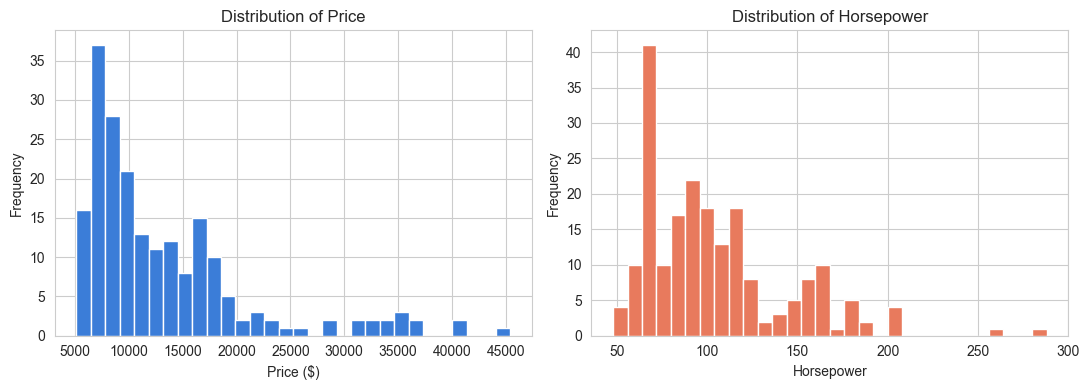

In [28]:
# Histograms of price and horsepower
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df_num['price'].dropna(), bins=30, color='#3b7dd8', edgecolor='white')
axes[0].set_title('Distribution of Price')
axes[0].set_xlabel('Price ($)'); axes[0].set_ylabel('Frequency')
axes[1].hist(df_num['horsepower'].dropna(), bins=30, color='#e87a5d', edgecolor='white')
axes[1].set_title('Distribution of Horsepower')
axes[1].set_xlabel('Horsepower'); axes[1].set_ylabel('Frequency')
plt.tight_layout(); plt.show()

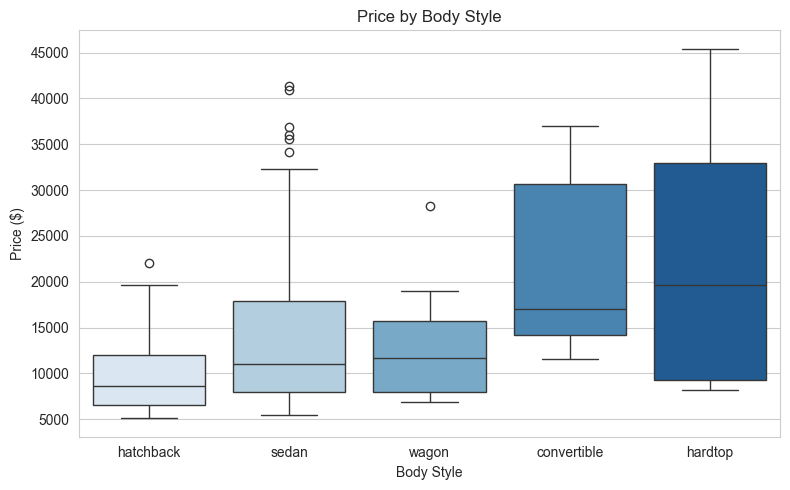

In [29]:
# Boxplot of price vs body-style, ordered by median price
order = df.groupby('body-style')['price'].apply(
    lambda s: pd.to_numeric(s, errors='coerce').median()).sort_values().index
plt.figure(figsize=(8, 5))
sns.boxplot(data=df.assign(price=pd.to_numeric(df['price'], errors='coerce')),
            x='body-style', y='price', order=order, palette='Blues')
plt.title('Price by Body Style')
plt.xlabel('Body Style'); plt.ylabel('Price ($)')
plt.tight_layout(); plt.show()

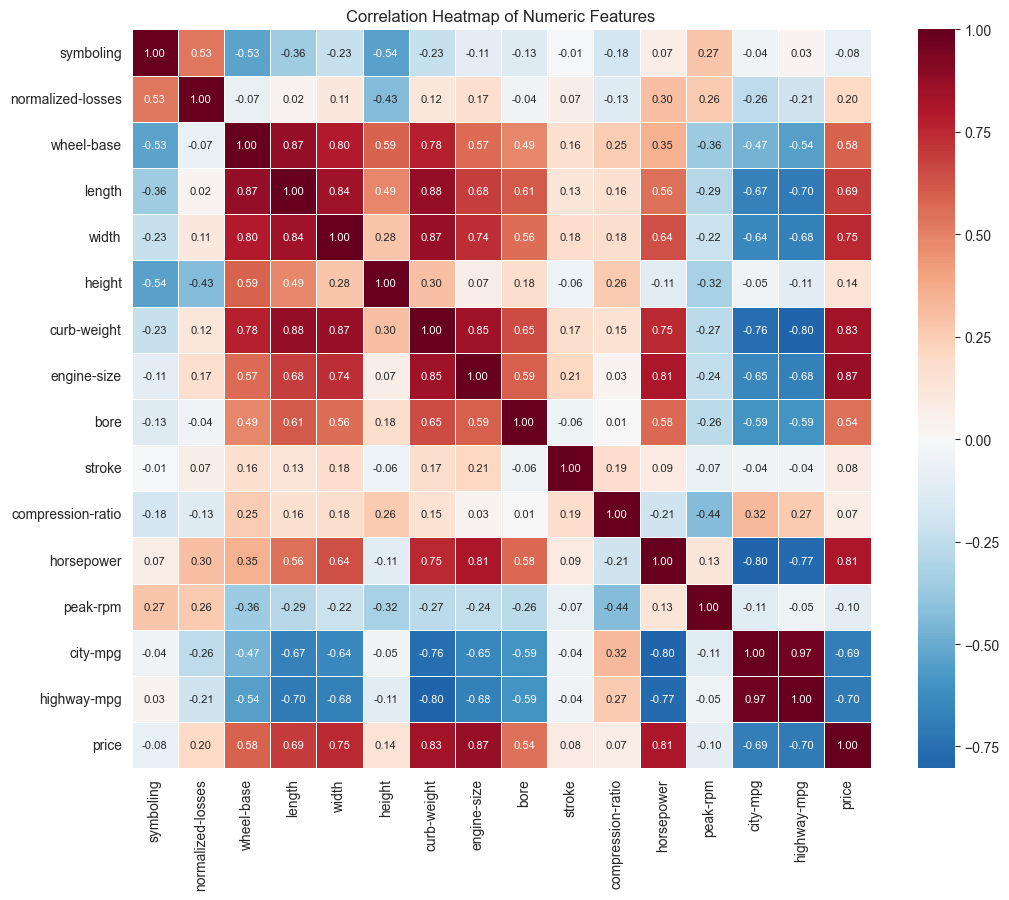

In [30]:
# Correlation heatmap of numeric features
corr = df_num.select_dtypes(include=np.number).corr()
plt.figure(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.4, annot_kws={'size': 8})
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout(); plt.show()

## 2. Task 2 — Data Preprocessing and Feature Engineering

### 2.1 Replace '?' with NaN and identify missing columns

In [31]:
df.replace('?', np.nan, inplace=True)
print('Columns with missing values:')
print(df.isna().sum()[df.isna().sum() > 0])

Columns with missing values:
normalized-losses    41
num-of-doors          2
bore                  4
stroke                4
horsepower            2
peak-rpm              2
price                 4
dtype: int64


### 2.2 Convert to numeric where needed

In [32]:
for c in ['normalized-losses','bore','stroke','horsepower','peak-rpm','price']:
    df[c] = pd.to_numeric(df[c], errors='coerce')

### 2.3 Mean imputation for numeric columns, mode imputation for num-of-doors

In [33]:
# Mean imputation
for c in ['normalized-losses','bore','stroke','horsepower','peak-rpm']:
    df[c] = df[c].fillna(df[c].mean())

# Mode imputation for the categorical column
df['num-of-doors'] = df['num-of-doors'].fillna(df['num-of-doors'].mode()[0])

# Drop the four rows where price (target) is unknown
df = df.dropna(subset=['price']).reset_index(drop=True)
print('After cleaning:', df.shape)

After cleaning: (201, 26)


### 2.4 Type conversions: price → float, horsepower → float

In [34]:
df['price']      = df['price'].astype(float)
df['horsepower'] = df['horsepower'].astype(float)
df.dtypes

symboling              int64
normalized-losses    float64
make                     str
fuel-type                str
aspiration               str
num-of-doors             str
body-style               str
drive-wheels             str
engine-location          str
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type              str
num-of-cylinders         str
engine-size            int64
fuel-system              str
bore                 float64
stroke               float64
compression-ratio    float64
horsepower           float64
peak-rpm             float64
city-mpg               int64
highway-mpg            int64
price                float64
dtype: object

### 2.5 Feature engineering: city-L/100km

In [35]:
df['city-L/100km'] = 235 / df['city-mpg']
df[['city-mpg', 'city-L/100km']].head()

,city-mpg,city-L/100km
0,21,11.190476
1,21,11.190476
2,19,12.368421
3,24,9.791667
4,18,13.055556


### 2.6 Binning horsepower (Low / Medium / High)

In [36]:
bins = np.linspace(df['horsepower'].min(), df['horsepower'].max(), 4)
labels = ['Low', 'Medium', 'High']
df['horsepower-binned'] = pd.cut(df['horsepower'], bins=bins, labels=labels, include_lowest=True)

print('Bin edges:', bins.round(1))
print(df['horsepower-binned'].value_counts())

Bin edges: [ 48.  119.3 190.7 262. ]
horsepower-binned
Low       153
Medium     43
High        5
Name: count, dtype: int64


### 2.7 Min-max normalisation on length, width and height

In [37]:
for c in ['length', 'width', 'height']:
    df[f'{c}_norm'] = (df[c] - df[c].min()) / (df[c].max() - df[c].min())

df[['length_norm', 'width_norm', 'height_norm']].describe().round(3)

,length_norm,width_norm,height_norm
count,201.000,201.000,201.000
mean,0.494,0.478,0.497
std,0.184,0.180,0.204
min,0.000,0.000,0.000
25%,0.384,0.325,0.350
50%,0.479,0.444,0.525
75%,0.633,0.538,0.642
max,1.000,1.000,1.000


## 3. Task 3 — Regression

### 3.1 Part A: Linear Regression on an 80/20 split

In [38]:
features = ['horsepower', 'engine-size', 'curb-weight', 'width', 'city-L/100km']
X = df[features]
y = df['price'].astype(float)

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.20, random_state=42)

lr = LinearRegression().fit(Xtr, ytr)
ypred_lr = lr.predict(Xte)

metrics_lr_80 = {
    'R2':  r2_score(yte, ypred_lr),
    'MAE': mean_absolute_error(yte, ypred_lr),
    'MSE': mean_squared_error(yte, ypred_lr),
}
print('Linear Regression — 80/20')
for k, v in metrics_lr_80.items():
    print(f'  {k}: {v:.4f}')

print('\nCoefficients:')
print(pd.Series(lr.coef_, index=features).round(2))

Linear Regression — 80/20
  R2: 0.7542
  MAE: 3849.5719
  MSE: 30066839.0910

Coefficients:
horsepower       -4.55
engine-size      86.65
curb-weight       0.76
width           645.34
city-L/100km    759.85
dtype: float64


### 3.2 Part B: Random Forest Regressor

In [39]:
rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(Xtr, ytr)
ypred_rf = rf.predict(Xte)

metrics_rf_80 = {
    'R2':  r2_score(yte, ypred_rf),
    'MAE': mean_absolute_error(yte, ypred_rf),
    'MSE': mean_squared_error(yte, ypred_rf),
}
print('Random Forest — 80/20')
for k, v in metrics_rf_80.items():
    print(f'  {k}: {v:.4f}')

Random Forest — 80/20
  R2: 0.9356
  MAE: 1812.9794
  MSE: 7880668.7384


### 3.3 Part C: Repeat with a 70/30 split

In [40]:
Xtr2, Xte2, ytr2, yte2 = train_test_split(X, y, test_size=0.30, random_state=42)

lr2 = LinearRegression().fit(Xtr2, ytr2)
ypred_lr2 = lr2.predict(Xte2)

rf2 = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf2.fit(Xtr2, ytr2)
ypred_rf2 = rf2.predict(Xte2)

metrics_lr_70 = {'R2': r2_score(yte2, ypred_lr2),
                 'MAE': mean_absolute_error(yte2, ypred_lr2),
                 'MSE': mean_squared_error(yte2, ypred_lr2)}
metrics_rf_70 = {'R2': r2_score(yte2, ypred_rf2),
                 'MAE': mean_absolute_error(yte2, ypred_rf2),
                 'MSE': mean_squared_error(yte2, ypred_rf2)}

summary = pd.DataFrame({
    'Model': ['Linear Reg. 80/20', 'Random Forest 80/20',
              'Linear Reg. 70/30', 'Random Forest 70/30'],
    'R2':    [metrics_lr_80['R2'], metrics_rf_80['R2'],
              metrics_lr_70['R2'], metrics_rf_70['R2']],
    'MAE':   [metrics_lr_80['MAE'], metrics_rf_80['MAE'],
              metrics_lr_70['MAE'], metrics_rf_70['MAE']],
    'MSE':   [metrics_lr_80['MSE'], metrics_rf_80['MSE'],
              metrics_lr_70['MSE'], metrics_rf_70['MSE']],
}).round(4)
summary

,Model,R2,MAE,MSE
0,Linear Reg. 80/20,0.7542,3849.5719,3.006684e+07
1,Random Forest 80/20,0.9356,1812.9794,7.880669e+06
2,Linear Reg. 70/30,0.7709,3111.5756,2.171986e+07
3,Random Forest 70/30,0.9269,1791.8320,6.928884e+06


### 3.4 Visualise the comparison

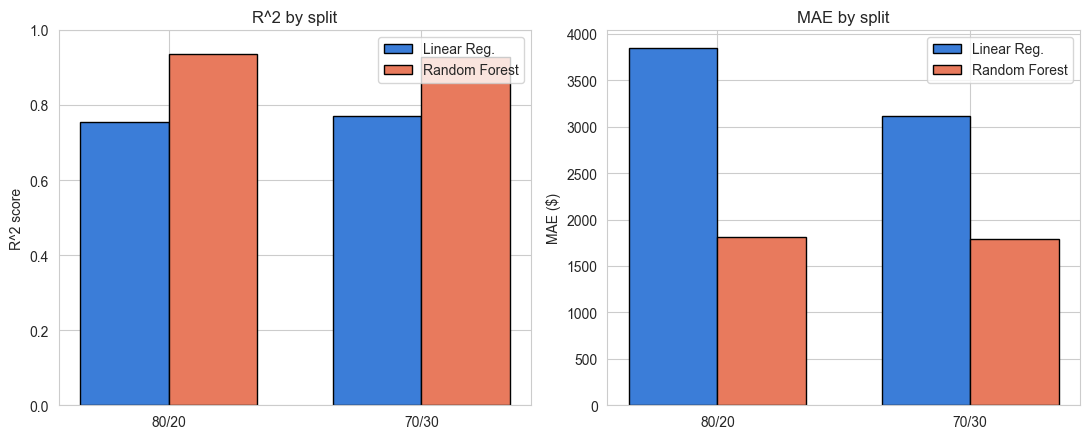

In [41]:
splits = ['80/20', '70/30']
lr_r2  = [metrics_lr_80['R2'], metrics_lr_70['R2']]
rf_r2  = [metrics_rf_80['R2'], metrics_rf_70['R2']]
lr_mae = [metrics_lr_80['MAE'], metrics_lr_70['MAE']]
rf_mae = [metrics_rf_80['MAE'], metrics_rf_70['MAE']]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
x = np.arange(len(splits)); w = 0.35
axes[0].bar(x - w/2, lr_r2, w, label='Linear Reg.',   color='#3b7dd8', edgecolor='black')
axes[0].bar(x + w/2, rf_r2, w, label='Random Forest', color='#e87a5d', edgecolor='black')
axes[0].set_xticks(x); axes[0].set_xticklabels(splits)
axes[0].set_ylabel('R^2 score'); axes[0].set_title('R^2 by split'); axes[0].legend()
axes[0].set_ylim(0, 1)

axes[1].bar(x - w/2, lr_mae, w, label='Linear Reg.',   color='#3b7dd8', edgecolor='black')
axes[1].bar(x + w/2, rf_mae, w, label='Random Forest', color='#e87a5d', edgecolor='black')
axes[1].set_xticks(x); axes[1].set_xticklabels(splits)
axes[1].set_ylabel('MAE ($)'); axes[1].set_title('MAE by split'); axes[1].legend()
plt.tight_layout(); plt.show()

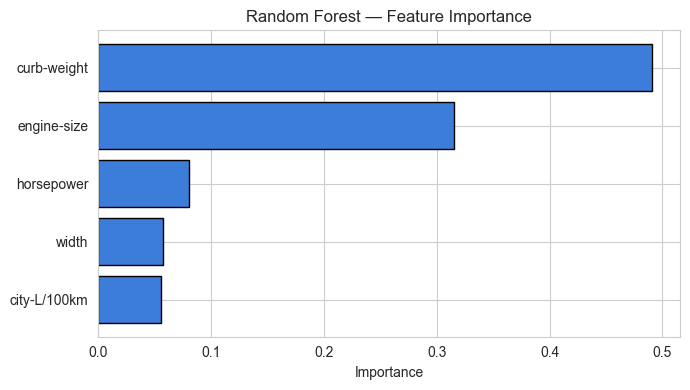

In [42]:
# Feature importance from the Random Forest
imp = pd.Series(rf.feature_importances_, index=features).sort_values()
plt.figure(figsize=(7, 4))
plt.barh(imp.index, imp.values, color='#3b7dd8', edgecolor='black')
plt.title('Random Forest — Feature Importance')
plt.xlabel('Importance')
plt.tight_layout(); plt.show()

## 4. Task 4 — Classification

### 4.1 Build the price categories with pd.qcut

In [43]:
df['price-category'] = pd.qcut(df['price'], 3, labels=['Low', 'Medium', 'High'])
df['price-category'].value_counts()

price-category
Low       67
Medium    67
High      67
Name: count, dtype: int64

### 4.2 Train a multinomial Logistic Regression

In [44]:
Xc = df[features]
yc = df['price-category']

Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(
    Xc, yc, test_size=0.20, stratify=yc, random_state=42)

scaler = StandardScaler().fit(Xc_tr)
clf = LogisticRegression(max_iter=2000, random_state=42)
clf.fit(scaler.transform(Xc_tr), yc_tr)

yc_pred = clf.predict(scaler.transform(Xc_te))
acc = accuracy_score(yc_te, yc_pred)
print(f'Accuracy: {acc:.4f}')
print()
print(classification_report(yc_te, yc_pred, digits=4))

Accuracy: 0.9512

              precision    recall  f1-score   support

        High     0.9231    0.9231    0.9231        13
         Low     1.0000    1.0000    1.0000        14
      Medium     0.9286    0.9286    0.9286        14

    accuracy                         0.9512        41
   macro avg     0.9505    0.9505    0.9505        41
weighted avg     0.9512    0.9512    0.9512        41



### 4.3 Confusion matrix

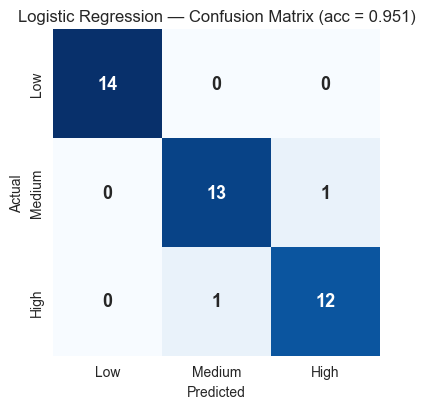

In [45]:
cm = confusion_matrix(yc_te, yc_pred, labels=['Low', 'Medium', 'High'])
plt.figure(figsize=(5, 4.2))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, square=True,
            xticklabels=['Low','Medium','High'], yticklabels=['Low','Medium','High'],
            annot_kws={'fontsize': 13, 'fontweight': 'bold'})
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title(f'Logistic Regression — Confusion Matrix (acc = {acc:.3f})')
plt.tight_layout(); plt.show()

## 5. Task 5 — Evaluation and Visualisation

### 5.1 Actual vs predicted prices for both regressors

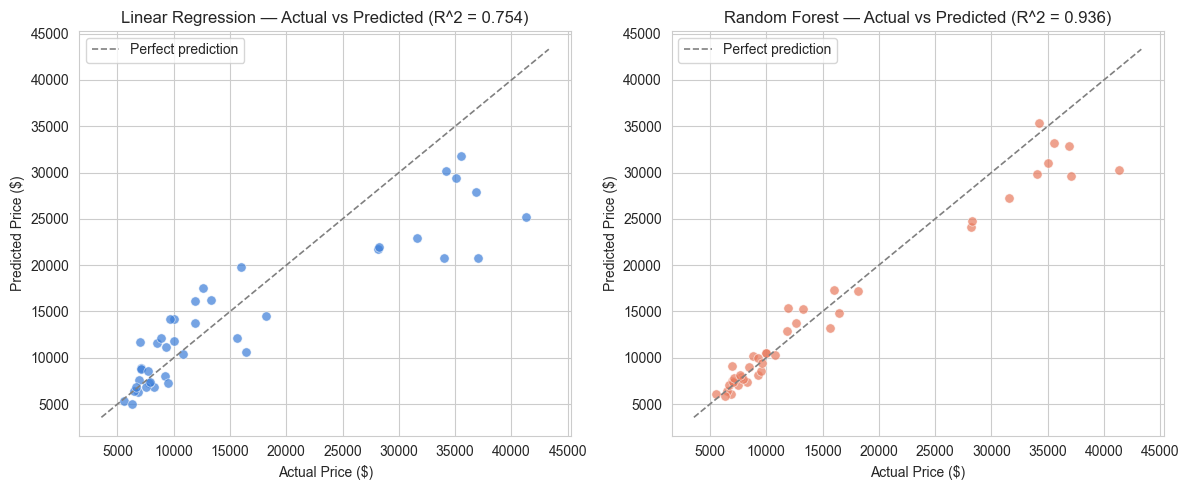

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, ypred, name, color in [
    (axes[0], ypred_lr, 'Linear Regression', '#3b7dd8'),
    (axes[1], ypred_rf, 'Random Forest',     '#e87a5d')
]:
    ax.scatter(yte, ypred, alpha=0.7, s=45, color=color,
               edgecolor='white', linewidth=0.5)
    lims = [yte.min() - 2000, yte.max() + 2000]
    ax.plot(lims, lims, '--', color='grey', lw=1.2, label='Perfect prediction')
    r2 = r2_score(yte, ypred)
    ax.set_title(f'{name} — Actual vs Predicted (R^2 = {r2:.3f})')
    ax.set_xlabel('Actual Price ($)'); ax.set_ylabel('Predicted Price ($)')
    ax.legend()
plt.tight_layout(); plt.show()

## 6. Task 6 — Business Insights and Recommendations

**What makes a car expensive?** Engine size, curb weight, width and horsepower are the dominant drivers. Body style matters too  convertibles and hardtops command higher median prices than hatchbacks.

**Which features should manufacturers focus on?** Bigger engines and wider chassis lift price most efficiently. Improving fuel economy actually shifts price the other way because the efficient end of the market is dominated by smaller, lighter, cheaper vehicles.

**How can customers use this model?** A buyer evaluating a used-car listing can plug engine-size, curb-weight, width, horsepower and fuel economy into the Random Forest and compare its prediction to the asking price. The Task 4 classifier is even simpler  it just tells the buyer which price band the car belongs in.

## 7. Task 7 — Conclusion

The Linear Regression explained 75% of price variance, the Random Forest explained 94%, and the multinomial Logistic Regression classified cars into price bands with 95% accuracy. The headline finding is that the relationship between car characteristics and price is genuinely non-linear, and tree-based models exploit that in a way ordinary least squares cannot.

**Limitations:** the dataset is small (201 usable rows) and old (1980s). The Random Forest R² of 0.94 is likely optimistic for a contemporary market. Mean imputation on `normalized-losses` will have flattened spread in that variable.

**Improvements:** refit the regression with categorical columns (make, body-style, drive-wheels) properly one-hot encoded; run a hyperparameter search on the Random Forest; try gradient-boosted trees (XGBoost or LightGBM); and switch from a single train/test split to k-fold cross-validation for tighter confidence intervals.
